In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Custom palette
COLORS = ['#F0B429', '#C87D0E', '#D81B7A', '#7B2D8B', '#9B8BB4',
          '#E85D9A', '#5B1F7A', '#F7D26A', '#B5478A', '#C9A0DC']
sns.set_palette(COLORS)
sns.set_theme(style="whitegrid")

# Load cleaned data
df = pd.read_csv('C:/churn_project/outputs/cleaned_data.csv')
print("Data loaded ✅")
print("Shape:", df.shape)

Data loaded ✅
Shape: (7043, 20)


In [2]:
# Tenure Groups
df['TenureGroup'] = pd.cut(df['tenure'], 
                            bins=[0, 12, 24, 36, 48, 60, 72],
                            labels=['0-12', '12-24', '24-36', 
                                    '36-48', '48-60', '60-72'],
                            include_lowest=True)

print("Tenure Groups created:")
print(df['TenureGroup'].value_counts().sort_index())

# CLV (Customer Lifetime Value)
# Formula: MonthlyCharges × Tenure
# Simple but powerful proxy for customer value
df['CLV'] = df['MonthlyCharges'] * df['tenure']

print("\nCLV Stats:")
print(df['CLV'].describe().round(2))

# Quick sanity check
print("\nSample of new features:")
print(df[['tenure', 'MonthlyCharges', 'TenureGroup', 'CLV']].head(10))

Tenure Groups created:
TenureGroup
0-12     2186
12-24    1024
24-36     832
36-48     762
48-60     832
60-72    1407
Name: count, dtype: int64

CLV Stats:
count    7043.00
mean     2279.58
std      2264.73
min         0.00
25%       394.00
50%      1393.60
75%      3786.10
max      8550.00
Name: CLV, dtype: float64

Sample of new features:
   tenure  MonthlyCharges TenureGroup      CLV
0       1           29.85        0-12    29.85
1      34           56.95       24-36  1936.30
2       2           53.85        0-12   107.70
3      45           42.30       36-48  1903.50
4       2           70.70        0-12   141.40
5       8           99.65        0-12   797.20
6      22           89.10       12-24  1960.20
7      10           29.75        0-12   297.50
8      28          104.80       24-36  2934.40
9      62           56.15       60-72  3481.30


In [3]:
# Copy dataframe so original stays clean
df_model = df.copy()

# Drop TenureGroup - it's categorical and we already have tenure as number
df_model.drop(columns=['TenureGroup'], inplace=True)

# Convert all Yes/No columns to 1/0
binary_cols = ['Partner', 'Dependents', 'PhoneService', 
               'PaperlessBilling']

for col in binary_cols:
    df_model[col] = df_model[col].map({'Yes': 1, 'No': 0})

# Handle MultipleLines - has 3 values
df_model['MultipleLines'] = df_model['MultipleLines'].map({
    'Yes': 1, 'No': 0, 'No phone service': 0
})

# Handle OnlineSecurity, OnlineBackup, DeviceProtection, 
# TechSupport, StreamingTV, StreamingMovies - have 3 values
three_val_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                  'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in three_val_cols:
    df_model[col] = df_model[col].map({
        'Yes': 1, 'No': 0, 'No internet service': 0
    })

# Label encode remaining categorical columns
le = LabelEncoder()
cat_cols = ['gender', 'InternetService', 'Contract', 'PaymentMethod']

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

print("Encoding done ✅")
print("\nData types check:")
print(df_model.dtypes)
print("\nAny nulls?", df_model.isnull().sum().sum())

Encoding done ✅

Data types check:
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
CLV                 float64
dtype: object

Any nulls? 0


In [4]:
# Define features and target
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Train/Test split - 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {X_train.shape[0]} rows")
print(f"Testing set: {X_test.shape[0]} rows")

# Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaling done ✅")
print("Ready for model training 🚀")

Features shape: (7043, 20)
Target shape: (7043,)

Training set: 5634 rows
Testing set: 1409 rows

Scaling done ✅
Ready for model training 🚀


In [6]:
# Train model
model = LogisticRegression(max_iter=1000, 
                           class_weight='balanced', 
                           random_state=42)
model.fit(X_train_scaled, y_train)
print("Model trained ✅")

# Predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]  # Churn probability

# Model Performance
print("\n=== MODEL PERFORMANCE ===")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model trained ✅

=== MODEL PERFORMANCE ===
ROC-AUC Score: 0.8400

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.50      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [7]:
# Attach churn probability to full dataset
X_all_scaled = scaler.transform(X)
df['ChurnProbability'] = model.predict_proba(X_all_scaled)[:, 1]

# Revenue at Risk = CLV × Churn Probability
df['RevenueAtRisk'] = df['CLV'] * df['ChurnProbability']

# Create segments based on CLV and Churn Probability
# Threshold: median CLV and 0.5 churn probability

clv_median = df['CLV'].median()
print(f"CLV Median: ₹{clv_median:.2f}")

def assign_segment(row):
    high_clv = row['CLV'] > clv_median
    high_churn = row['ChurnProbability'] >= 0.5
    
    if high_clv and high_churn:
        return '🚨 Critical'
    elif high_clv and not high_churn:
        return '💎 Loyal'
    elif not high_clv and high_churn:
        return '⚠️ At Risk'
    else:
        return '👍 Safe'

df['Segment'] = df.apply(assign_segment, axis=1)

# Summary
print("\n=== SEGMENT SUMMARY ===")
segment_summary = df.groupby('Segment').agg(
    CustomerCount=('Churn', 'count'),
    AvgCLV=('CLV', 'mean'),
    AvgChurnProb=('ChurnProbability', 'mean'),
    TotalRevenueAtRisk=('RevenueAtRisk', 'sum')
).round(2)

print(segment_summary)
print(f"\nTotal Revenue at Risk: ₹{df['RevenueAtRisk'].sum():,.2f}")

CLV Median: ₹1393.60

=== SEGMENT SUMMARY ===
            CustomerCount   AvgCLV  AvgChurnProb  TotalRevenueAtRisk
Segment                                                             
⚠️ At Risk           1847   431.46          0.75           600924.30
👍 Safe               1675   586.42          0.21           150667.74
💎 Loyal              2453  4381.22          0.18          1960045.98
🚨 Critical           1068  3304.13          0.69          2375011.47

Total Revenue at Risk: ₹5,086,649.50


C:\Users\aasth\AppData\Local\Temp\ipykernel_32692\3113166007.py:66: UserWarning: Glyph 128142 (\N{GEM STONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\aasth\AppData\Local\Temp\ipykernel_32692\3113166007.py:66: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\aasth\AppData\Local\Temp\ipykernel_32692\3113166007.py:66: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\aasth\AppData\Local\Temp\ipykernel_32692\3113166007.py:66: UserWarning: Glyph 128077 (\N{THUMBS UP SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\aasth\AppData\Local\Temp\ipykernel_32692\3113166007.py:66: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\aasth\AppData\Local\Temp\ipykernel_32692\3113166007.py:67: UserWarning: Glyph 128142 (\N{GEM STONE}) missing from font(s) Arial.
  plt.savefig('C:/churn_project/

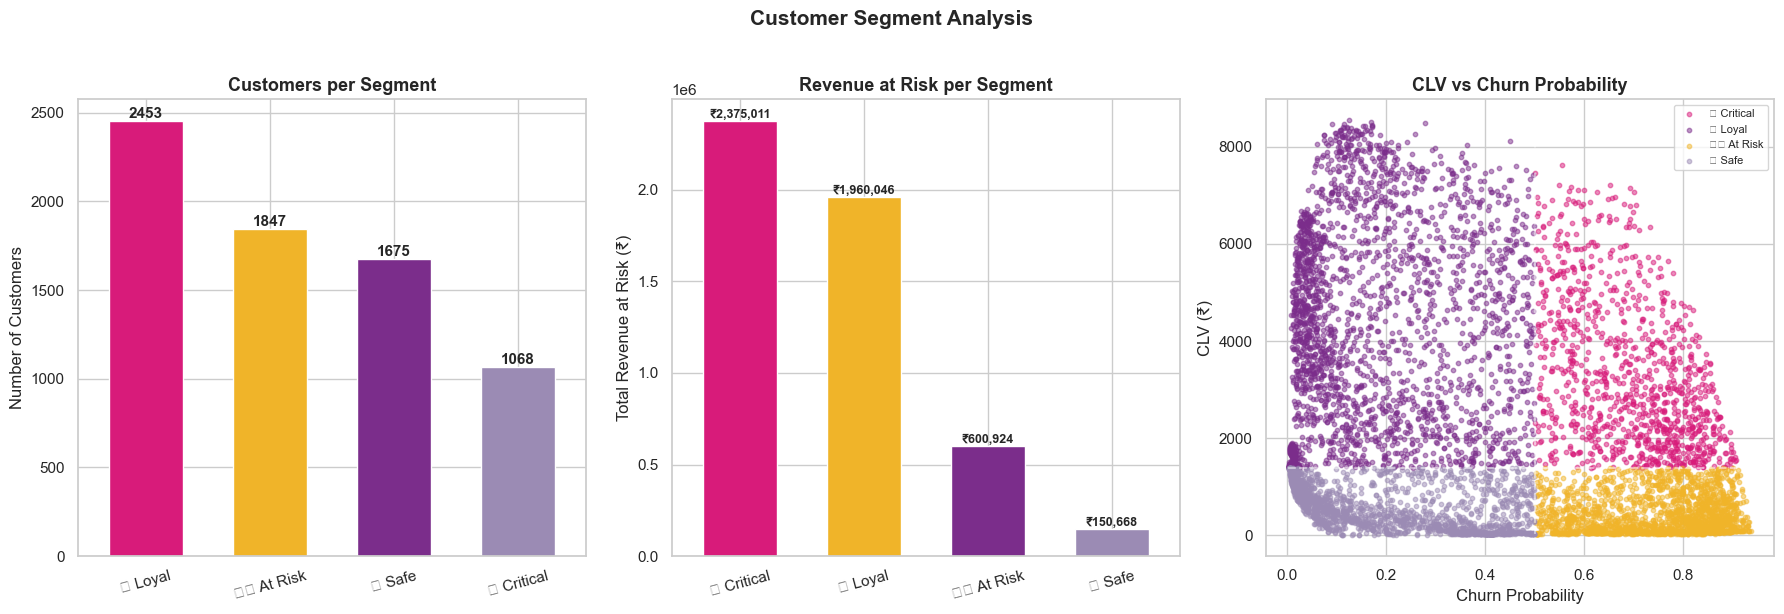

Chart saved ✅


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Chart 1 - Customer count per segment
segment_counts = df['Segment'].value_counts()
ax1 = segment_counts.plot(kind='bar', ax=axes[0],
                          color=['#D81B7A', '#F0B429', 
                                 '#7B2D8B', '#9B8BB4'],
                          edgecolor='white', width=0.6)

for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', 
                fontsize=11, fontweight='bold')

axes[0].set_title('Customers per Segment', 
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=15)

# Chart 2 - Revenue at Risk per segment
revenue_risk = df.groupby('Segment')['RevenueAtRisk'].sum().sort_values(ascending=False)
ax2 = revenue_risk.plot(kind='bar', ax=axes[1],
                        color=['#D81B7A', '#F0B429', 
                               '#7B2D8B', '#9B8BB4'],
                        edgecolor='white', width=0.6)

for p in axes[1].patches:
    axes[1].annotate(f'₹{p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', 
                fontsize=9, fontweight='bold')

axes[1].set_title('Revenue at Risk per Segment', 
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Total Revenue at Risk (₹)')
axes[1].tick_params(axis='x', rotation=15)

# Chart 3 - Scatter plot CLV vs Churn Probability
colors_map = {
    '🚨 Critical': '#D81B7A',
    '💎 Loyal': '#7B2D8B',
    '⚠️ At Risk': '#F0B429',
    '👍 Safe': '#9B8BB4'
}

for segment, color in colors_map.items():
    mask = df['Segment'] == segment
    axes[2].scatter(df[mask]['ChurnProbability'],
                   df[mask]['CLV'],
                   c=color, label=segment,
                   alpha=0.5, s=10)

axes[2].axvline(x=0.5, color='white', linestyle='--', alpha=0.5)
axes[2].axhline(y=clv_median, color='white', linestyle='--', alpha=0.5)
axes[2].set_title('CLV vs Churn Probability', 
                   fontsize=13, fontweight='bold')
axes[2].set_xlabel('Churn Probability')
axes[2].set_ylabel('CLV (₹)')
axes[2].legend(fontsize=8)

plt.suptitle('Customer Segment Analysis', 
              fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('C:/churn_project/outputs/segment_analysis.png', dpi=150)
plt.show()

print("Chart saved ✅")

In [10]:
print("=" * 55)
print("      BUSINESS IMPACT SIMULATION")
print("=" * 55)

# Current state
critical = df[df['Segment'] == '🚨 Critical']
total_customers = len(df)
critical_customers = len(critical)
total_revenue_at_risk = df['RevenueAtRisk'].sum()
critical_revenue_at_risk = critical['RevenueAtRisk'].sum()

print(f"\n📊 CURRENT STATE:")
print(f"   Total Customers          : {total_customers:,}")
print(f"   Critical Customers       : {critical_customers:,}")
print(f"   Total Revenue at Risk    : ₹{total_revenue_at_risk:,.2f}")
print(f"   Critical Revenue at Risk : ₹{critical_revenue_at_risk:,.2f}")

# Simulation - what if we retain X% of critical customers
print(f"\n💡 RETENTION SIMULATION (Critical Segment):")
print(f"{'Retention Rate':<20} {'Customers Saved':<20} {'Revenue Saved'}")
print("-" * 55)

for rate in [0.05, 0.10, 0.15, 0.20, 0.25]:
    customers_saved = int(critical_customers * rate)
    revenue_saved = critical_revenue_at_risk * rate
    print(f"{rate*100:.0f}%{'':<18} {customers_saved:<20} ₹{revenue_saved:,.2f}")

# Retention cost vs benefit analysis
print(f"\n💰 COST vs BENEFIT ANALYSIS:")
print(f"   Assumption: Retention offer costs ₹500 per customer")
print("-" * 55)

retention_cost_per_customer = 500

for rate in [0.05, 0.10, 0.20]:
    customers_saved = int(critical_customers * rate)
    revenue_saved = critical_revenue_at_risk * rate
    total_cost = customers_saved * retention_cost_per_customer
    net_benefit = revenue_saved - total_cost
    roi = (net_benefit / total_cost) * 100 if total_cost > 0 else 0
    
    print(f"\n   {rate*100:.0f}% Retention Rate:")
    print(f"   Customers Saved  : {customers_saved}")
    print(f"   Revenue Saved    : ₹{revenue_saved:,.2f}")
    print(f"   Retention Cost   : ₹{total_cost:,.2f}")
    print(f"   Net Benefit      : ₹{net_benefit:,.2f}")
    print(f"   ROI              : {roi:.1f}%")

print("\n" + "=" * 55)
print("Simulation complete ✅")

      BUSINESS IMPACT SIMULATION

📊 CURRENT STATE:
   Total Customers          : 7,043
   Critical Customers       : 1,068
   Total Revenue at Risk    : ₹5,086,649.50
   Critical Revenue at Risk : ₹2,375,011.47

💡 RETENTION SIMULATION (Critical Segment):
Retention Rate       Customers Saved      Revenue Saved
-------------------------------------------------------
5%                   53                   ₹118,750.57
10%                   106                  ₹237,501.15
15%                   160                  ₹356,251.72
20%                   213                  ₹475,002.29
25%                   267                  ₹593,752.87

💰 COST vs BENEFIT ANALYSIS:
   Assumption: Retention offer costs ₹500 per customer
-------------------------------------------------------

   5% Retention Rate:
   Customers Saved  : 53
   Revenue Saved    : ₹118,750.57
   Retention Cost   : ₹26,500.00
   Net Benefit      : ₹92,250.57
   ROI              : 348.1%

   10% Retention Rate:
   Customers Saved

In [11]:
# Select all columns needed for Power BI
df_powerbi = df[[
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'tenure', 'Contract', 'PaymentMethod',
    'MonthlyCharges', 'TotalCharges',
    'Churn', 'CLV', 'TenureGroup',
    'ChurnProbability', 'RevenueAtRisk', 'Segment'
]]

# Clean segment labels for Power BI (remove emojis)
df_powerbi = df_powerbi.copy()
df_powerbi['Segment'] = df_powerbi['Segment'].str.replace(
    '🚨 ', '').str.replace(
    '💎 ', '').str.replace(
    '⚠️ ', '').str.replace(
    '👍 ', '')

# Save
df_powerbi.to_csv('C:/churn_project/outputs/powerbi_data.csv', index=False)

print("Power BI dataset saved ✅")
print("Shape:", df_powerbi.shape)
print("\nColumns:")
print(df_powerbi.columns.tolist())
print("\nSegment values:")
print(df_powerbi['Segment'].value_counts())
print("\nSample:")
print(df_powerbi.head())

Power BI dataset saved ✅
Shape: (7043, 15)

Columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'Contract', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'CLV', 'TenureGroup', 'ChurnProbability', 'RevenueAtRisk', 'Segment']

Segment values:
Segment
Loyal       2453
At Risk     1847
Safe        1675
Critical    1068
Name: count, dtype: int64

Sample:
   gender  SeniorCitizen Partner Dependents  tenure        Contract  \
0  Female              0     Yes         No       1  Month-to-month   
1    Male              0      No         No      34        One year   
2    Male              0      No         No       2  Month-to-month   
3    Male              0      No         No      45        One year   
4  Female              0      No         No       2  Month-to-month   

               PaymentMethod  MonthlyCharges  TotalCharges  Churn      CLV  \
0           Electronic check           29.85         29.85      0    29.85   
1               Mailed check   